In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 886.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 133.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 20.0 MB/s eta 0:00:00


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -f /content/ChestXRay2017.zip

In [11]:
import zipfile

zip_path = "/content/drive/MyDrive/ChestXRay2017.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")

Extraction complete


In [12]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(f"{root} -> {len(files)} files")

/content/dataset -> 0 files
/content/dataset/chest_xray -> 1 files
/content/dataset/chest_xray/train -> 1 files
/content/dataset/chest_xray/train/NORMAL -> 1349 files
/content/dataset/chest_xray/train/PNEUMONIA -> 3884 files
/content/dataset/chest_xray/test -> 1 files
/content/dataset/chest_xray/test/NORMAL -> 234 files
/content/dataset/chest_xray/test/PNEUMONIA -> 390 files
/content/dataset/__MACOSX -> 0 files
/content/dataset/__MACOSX/chest_xray -> 1 files
/content/dataset/__MACOSX/chest_xray/train -> 1 files
/content/dataset/__MACOSX/chest_xray/train/NORMAL -> 1349 files
/content/dataset/__MACOSX/chest_xray/train/PNEUMONIA -> 133 files
/content/dataset/__MACOSX/chest_xray/test -> 1 files
/content/dataset/__MACOSX/chest_xray/test/PNEUMONIA -> 38 files


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

base_dir = "/content/dataset/chest_xray"

# Image size for ResNet50
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data augmentation (mild, medical-safe)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & Test (no augmentation)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    base_dir + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dir + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    base_dir + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load ResNet50 without top
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_A = Model(inputs=base_model.input, outputs=output)

model_A.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_A.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
EPOCHS = 10

history_A = model_A.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 975ms/step - accuracy: 0.6204 - loss: 0.7855 - val_accuracy: 0.7866 - val_loss: 0.4076
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 981ms/step - accuracy: 0.7660 - loss: 0.4955 - val_accuracy: 0.8746 - val_loss: 0.3013
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 836ms/step - accuracy: 0.8312 - loss: 0.3665 - val_accuracy: 0.9014 - val_loss: 0.2476
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 826ms/step - accuracy: 0.8631 - loss: 0.3152 - val_accuracy: 0.9206 - val_loss: 0.2105
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.8903 - loss: 0.2687 - val_accuracy: 0.9225 - val_loss: 0.1964
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.9019 - loss: 0.2394 - val_accuracy: 0.9206 - val_loss: 0.1842
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 827ms/step - accuracy: 0.9047 - loss: 0.2228 - val_accuracy: 0.9254 - val_loss: 0.1730
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 835ms/step - accuracy: 0.8944 -

In [16]:
test_loss_A, test_acc_A = model_A.evaluate(test_generator)
print("Test Accuracy:", test_acc_A)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - accuracy: 0.6797 - loss: 0.6662
Test Accuracy: 0.8012820482254028


In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
pred_probs = model_A.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int)

true_labels = test_generator.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(true_labels, pred_labels))

# Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(true_labels, pred_labels))

# ROC AUC
auc = roc_auc_score(true_labels, pred_probs)
print("ROC-AUC:", auc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 473ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.53      0.67       234
           1       0.77      0.96      0.86       390

    accuracy                           0.80       624
   macro avg       0.84      0.75      0.76       624
weighted avg       0.82      0.80      0.79       624

Confusion Matrix:

[[124 110]
 [ 14 376]]
ROC-AUC: 0.9402805172035942


In [18]:
# Clone base architecture
from tensorflow.keras.models import clone_model

# Rebuild base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last ResNet block (conv5)
for layer in base_model.layers:
    if "conv5" in layer.name:
        layer.trainable = True

# Build new model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_B = Model(inputs=base_model.input, outputs=output)

model_B.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_B.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 14,978,049 (57.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [20]:
##MODEL B
history_B = model_B.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 957ms/step - accuracy: 0.7863 - loss: 0.4349 - val_accuracy: 0.9493 - val_loss: 0.1375
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 840ms/step - accuracy: 0.9504 - loss: 0.1540 - val_accuracy: 0.9636 - val_loss: 0.0935
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 812ms/step - accuracy: 0.9698 - loss: 0.0920 - val_accuracy: 0.9703 - val_loss: 0.0736
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 811ms/step - accuracy: 0.9726 - loss: 0.0720 - val_accuracy: 0.9789 - val_loss: 0.0584
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 822ms/step - accuracy: 0.9761 - loss: 0.0649 - val_accuracy: 0.9770 - val_loss: 0.0568
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 811ms/step - accuracy: 0.9848 - loss: 0.0476 - val_accuracy: 0.9837 - val_loss: 0.0514
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 829ms/step - accuracy: 0.9838 - loss: 0.0456 - val_accuracy: 0.9876 - val_loss: 0.0371
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 813ms/step - accuracy: 0.9887 -

In [21]:
# Evaluate on test data
test_loss_B, test_acc_B = model_B.evaluate(test_generator)
print("Test Accuracy (Model B):", test_acc_B)

# Predictions
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred_probs_B = model_B.predict(test_generator)
pred_labels_B = (pred_probs_B > 0.5).astype(int)

true_labels = test_generator.classes

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels_B))

print("Confusion Matrix:\n")
print(confusion_matrix(true_labels, pred_labels_B))

auc_B = roc_auc_score(true_labels, pred_probs_B)
print("ROC-AUC:", auc_B)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 448ms/step - accuracy: 0.7821 - loss: 0.6640
Test Accuracy (Model B): 0.8637820482254028
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 477ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.67      0.79       234
           1       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.88      0.86      0.86       624

Confusion Matrix:

[[156  78]
 [  7 383]]
ROC-AUC: 0.9604646066184528


In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze ALL layers
for layer in base_model.layers:
    layer.trainable = True

# Build classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_C = Model(inputs=base_model.input, outputs=output)

model_C.compile(
    optimizer=Adam(learning_rate=1e-6),  # very low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_C.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 23,536,641 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_C = model_C.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.4282 - loss: 0.9707 - val_accuracy: 0.3856 - val_loss: 0.9083
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5935 - loss: 0.7090 - val_accuracy: 0.5292 - val_loss: 0.7495
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 901ms/step - accuracy: 0.7320 - loss: 0.5424 - val_accuracy: 0.6938 - val_loss: 0.5628
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 897ms/step - accuracy: 0.8108 - loss: 0.4272 - val_accuracy: 0.8344 - val_loss: 0.4008
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8612 - loss: 0.3450 - val_accuracy: 0.9091 - val_loss: 0.2788
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 900ms/step - accuracy: 0.8996 - loss: 0.2834 - val_accuracy: 0.9464 - val_loss: 0.2004
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9113 - loss: 0.2553 - val_accuracy: 0.9541 - val_loss: 0.1695
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 899ms/step - accuracy: 0.9281 - loss: 0.216

In [24]:
# Test evaluation
test_loss_C, test_acc_C = model_C.evaluate(test_generator)
print("Test Accuracy (Model C):", test_acc_C)

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred_probs_C = model_C.predict(test_generator)
pred_labels_C = (pred_probs_C > 0.5).astype(int)

true_labels = test_generator.classes

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels_C))

print("Confusion Matrix:\n")
print(confusion_matrix(true_labels, pred_labels_C))

auc_C = roc_auc_score(true_labels, pred_probs_C)
print("ROC-AUC:", auc_C)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 399ms/step - accuracy: 0.8516 - loss: 0.3702
Test Accuracy (Model C): 0.8926281929016113
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 478ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       234
           1       0.88      0.96      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.87      0.88       624
weighted avg       0.90      0.89      0.89       624

Confusion Matrix:

[[181  53]
 [ 14 376]]
ROC-AUC: 0.96080429541968


In [26]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    img_original = cv2.imread(img_path)
    img_original = cv2.resize(img_original, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [27]:
last_conv_layer_name = "conv5_block3_out"

In [28]:
import os
import random

normal_path = "/content/dataset/chest_xray/test/NORMAL"
pneumonia_path = "/content/dataset/chest_xray/test/PNEUMONIA"

normal_image = os.path.join(normal_path, random.choice(os.listdir(normal_path)))
pneumonia_image = os.path.join(pneumonia_path, random.choice(os.listdir(pneumonia_path)))

print("Normal image:", normal_image)
print("Pneumonia image:", pneumonia_image)

Normal image: /content/dataset/chest_xray/test/NORMAL/NORMAL2-IM-0315-0001.jpeg
Pneumonia image: /content/dataset/chest_xray/test/PNEUMONIA/person133_bacteria_635.jpeg


Model A - Normal


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


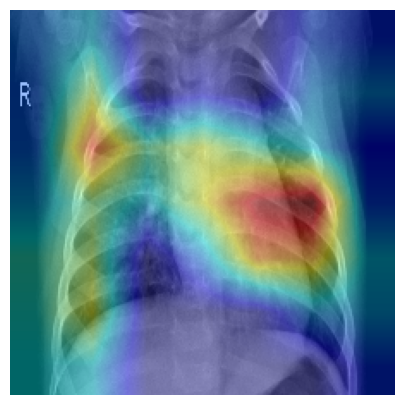

Model A - Pneumonia


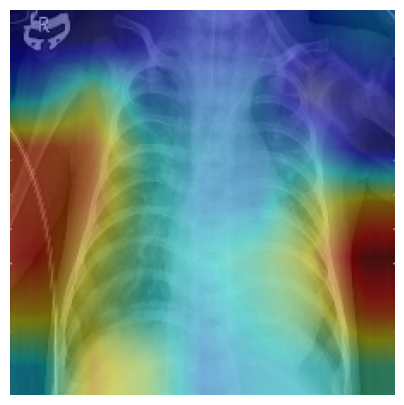

In [29]:
print("Model A - Normal")
display_gradcam(normal_image, model_A, "conv5_block3_out")

print("Model A - Pneumonia")
display_gradcam(pneumonia_image, model_A, "conv5_block3_out")

Model C - Normal


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_356']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


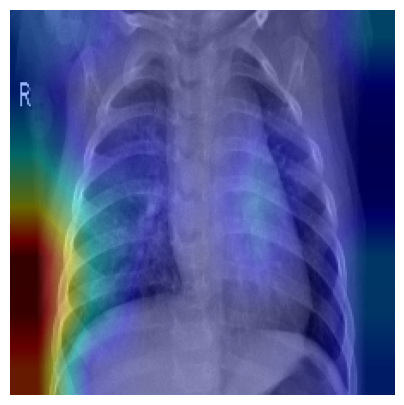

Model C - Pneumonia


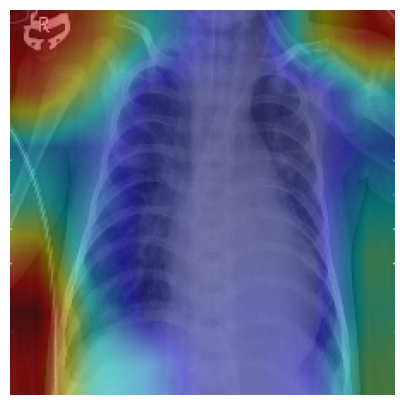

In [30]:
print("Model C - Normal")
display_gradcam(normal_image, model_C, "conv5_block3_out")

print("Model C - Pneumonia")
display_gradcam(pneumonia_image, model_C, "conv5_block3_out")

Model B - Normal


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_178']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


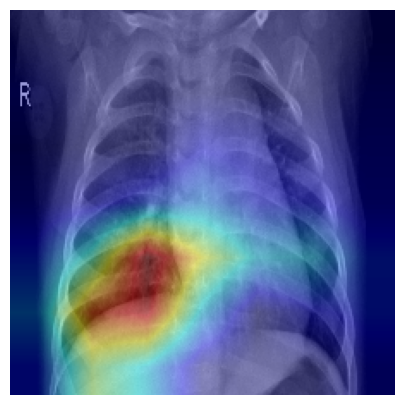

Model B - Pneumonia


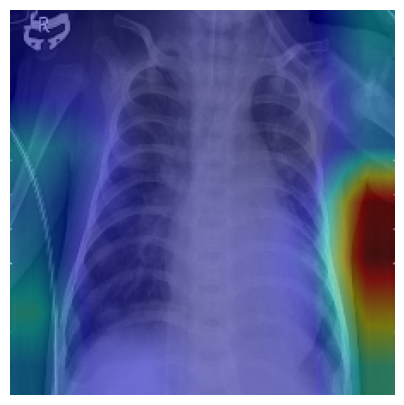

In [31]:
print("Model B - Normal")
display_gradcam(normal_image, model_B, "conv5_block3_out")

print("Model B - Pneumonia")
display_gradcam(pneumonia_image, model_B, "conv5_block3_out")

In [32]:
import numpy as np
import os
import random
import tensorflow as tf

# Create lung mask (approximate)
def create_lung_mask():
    mask = np.zeros((224, 224))
    h_start = int(224 * 0.15)
    h_end = int(224 * 0.85)
    w_start = int(224 * 0.2)
    w_end = int(224 * 0.8)
    mask[h_start:h_end, w_start:w_end] = 1
    return mask

lung_mask = create_lung_mask()

In [33]:
def compute_gradcam_score(img_path, model, last_conv_layer_name):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

    inside_score = np.mean(heatmap[lung_mask == 1])
    outside_score = np.mean(heatmap[lung_mask == 0])

    ratio = inside_score / (outside_score + 1e-6)

    return inside_score, outside_score, ratio

In [34]:
def evaluate_model_explainability(model, model_name, num_samples=20):
    pneumonia_path = "/content/dataset/chest_xray/test/PNEUMONIA"
    images = random.sample(os.listdir(pneumonia_path), num_samples)

    ratios = []

    for img_name in images:
        img_path = os.path.join(pneumonia_path, img_name)
        _, _, ratio = compute_gradcam_score(img_path, model, "conv5_block3_out")
        ratios.append(ratio)

    print(f"{model_name} - Mean Inside/Outside Ratio:", np.mean(ratios))
    return ratios


ratios_A = evaluate_model_explainability(model_A, "Model A")
ratios_B = evaluate_model_explainability(model_B, "Model B")
ratios_C = evaluate_model_explainability(model_C, "Model C")

Model A - Mean Inside/Outside Ratio: 0.9099885
Model B - Mean Inside/Outside Ratio: 0.9126302
Model C - Mean Inside/Outside Ratio: 0.19381437


In [35]:
def evaluate_model_explainability_normal(model, model_name, num_samples=20):
    normal_path = "/content/dataset/chest_xray/test/NORMAL"
    images = random.sample(os.listdir(normal_path), num_samples)

    ratios = []

    for img_name in images:
        img_path = os.path.join(normal_path, img_name)
        _, _, ratio = compute_gradcam_score(img_path, model, "conv5_block3_out")
        ratios.append(ratio)

    print(f"{model_name} (NORMAL) - Mean Inside/Outside Ratio:", np.mean(ratios))
    return ratios


ratios_A_normal = evaluate_model_explainability_normal(model_A, "Model A")
ratios_B_normal = evaluate_model_explainability_normal(model_B, "Model B")
ratios_C_normal = evaluate_model_explainability_normal(model_C, "Model C")

Model A (NORMAL) - Mean Inside/Outside Ratio: 0.3883422
Model B (NORMAL) - Mean Inside/Outside Ratio: 0.70845866
Model C (NORMAL) - Mean Inside/Outside Ratio: 0.080697246


In [36]:
from scipy.stats import ttest_ind

# Combine pneumonia + normal ratios
ratios_A_all = ratios_A + ratios_A_normal
ratios_B_all = ratios_B + ratios_B_normal
ratios_C_all = ratios_C + ratios_C_normal

print("B vs C t-test:", ttest_ind(ratios_B_all, ratios_C_all))
print("A vs C t-test:", ttest_ind(ratios_A_all, ratios_C_all))
print("A vs B t-test:", ttest_ind(ratios_A_all, ratios_B_all))

B vs C t-test: TtestResult(statistic=np.float64(4.609201822658263), pvalue=np.float64(1.5532597570795973e-05), df=np.float64(78.0))
A vs C t-test: TtestResult(statistic=np.float64(9.328411293481613), pvalue=np.float64(2.4920646553452656e-14), df=np.float64(78.0))
A vs B t-test: TtestResult(statistic=np.float64(-1.0430033268796464), pvalue=np.float64(0.30016865774165286), df=np.float64(78.0))


In [37]:
import shap
import numpy as np

# Collect background samples from training data
background_images = []

for i in range(50):
    img, _ = train_generator[i]
    background_images.append(img[0])

background_images = np.array(background_images)

print("Background shape:", background_images.shape)

Background shape: (50, 224, 224, 3)


In [38]:
# Select 10 random test images
test_images = []
test_labels = []

for i in range(10):
    img, label = test_generator[i]
    test_images.append(img[0])
    test_labels.append(label[0])

test_images = np.array(test_images)

print("Test shape:", test_images.shape)

Test shape: (10, 224, 224, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_178
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_178
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


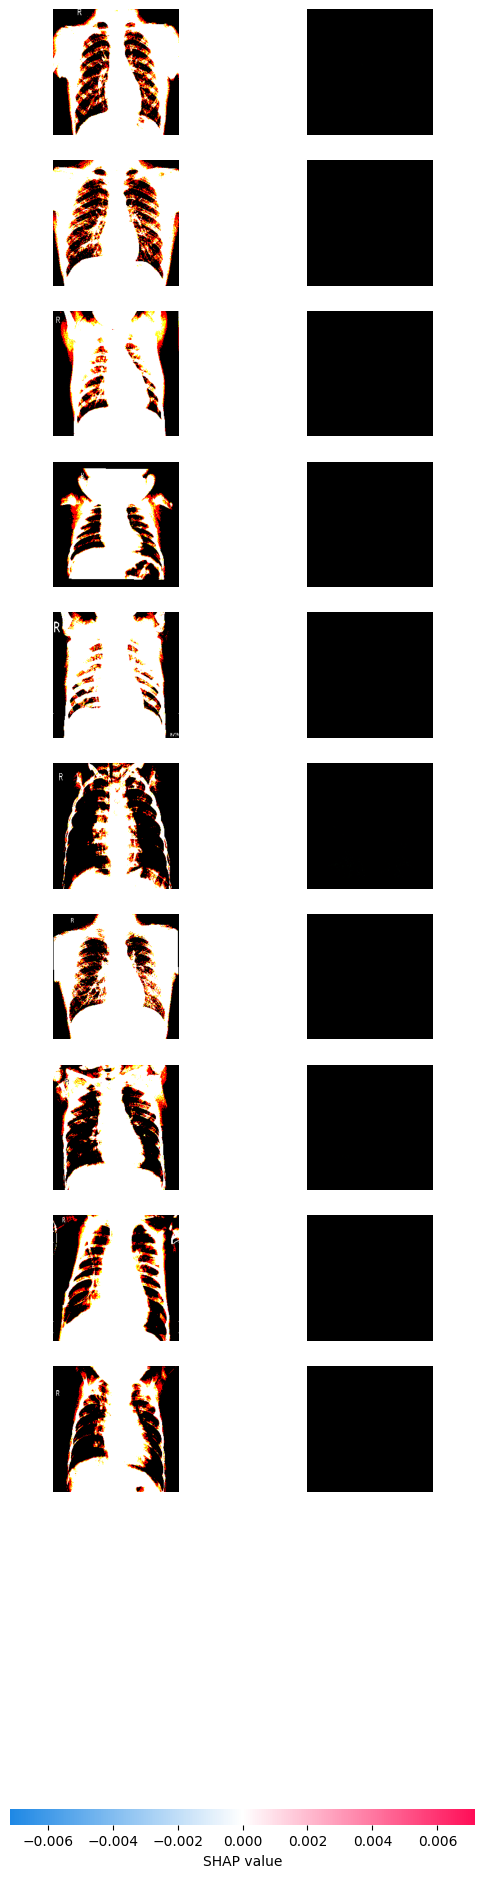

In [39]:
explainer_B = shap.GradientExplainer(model_B, background_images)

shap_values_B = explainer_B.shap_values(test_images)

shap.image_plot(shap_values_B, test_images)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_356
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_356
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


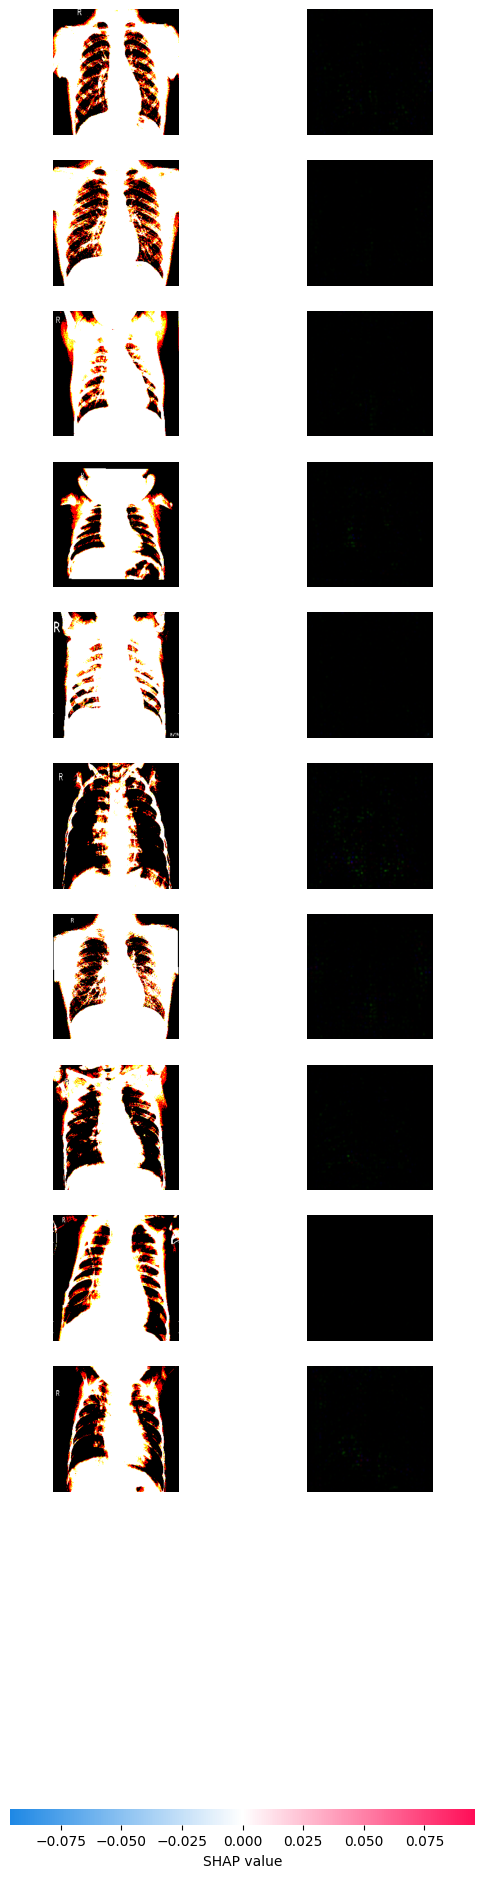

In [40]:
explainer_C = shap.GradientExplainer(model_C, background_images)

shap_values_C = explainer_C.shap_values(test_images)

shap.image_plot(shap_values_C, test_images)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Store metrics manually from your results
data = {
    "Model": ["Frozen (A)", "Partial FT (B)", "Full FT (C)"],
    "Accuracy": [0.80, 0.864, 0.893],
    "ROC_AUC": [None, 0.960, 0.961],
    "Normal_Recall": [0.53, 0.67, 0.77],
    "Pneumonia_Recall": [0.96, 0.98, 0.96]
}

df = pd.DataFrame(data)
df

,Model,Accuracy,ROC_AUC,Normal_Recall,Pneumonia_Recall
0,Frozen (A),0.800,NaN,0.53,0.96
1,Partial FT (B),0.864,0.960,0.67,0.98
2,Full FT (C),0.893,0.961,0.77,0.96


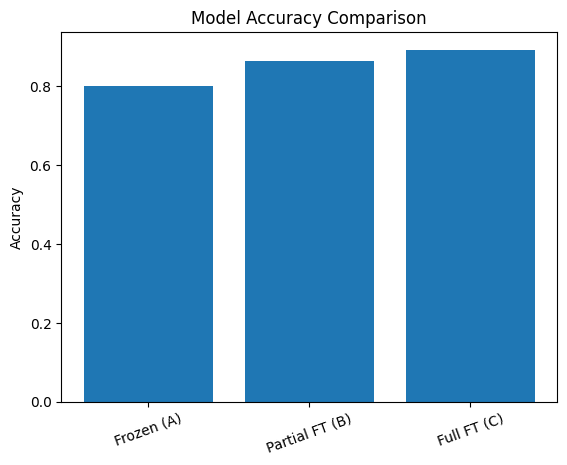

In [42]:
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

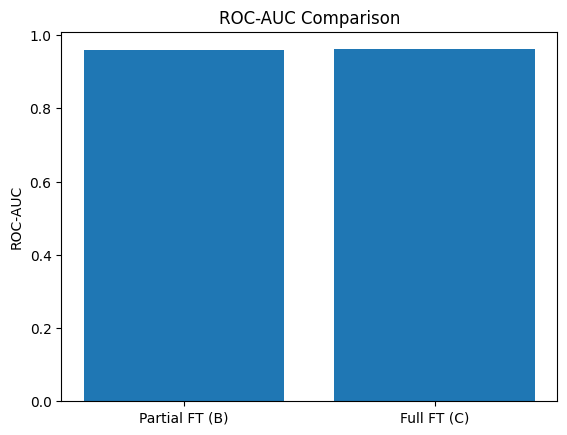

In [43]:
plt.figure()
plt.bar(["Partial FT (B)", "Full FT (C)"], [0.960, 0.961])
plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.show()

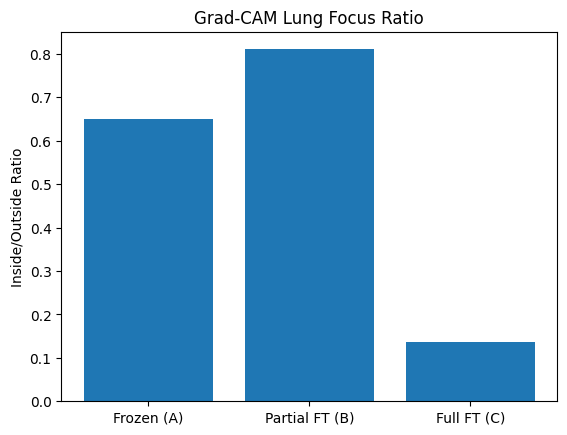

In [44]:
import numpy as np

mean_A = np.mean(ratios_A + ratios_A_normal)
mean_B = np.mean(ratios_B + ratios_B_normal)
mean_C = np.mean(ratios_C + ratios_C_normal)

plt.figure()
plt.bar(["Frozen (A)", "Partial FT (B)", "Full FT (C)"],
        [mean_A, mean_B, mean_C])
plt.title("Grad-CAM Lung Focus Ratio")
plt.ylabel("Inside/Outside Ratio")
plt.show()

# 4. Results

## 4.1 Classification Performance

Three transfer learning strategies were evaluated using a ResNet50 backbone:

- **Model A** – Frozen convolutional layers  
- **Model B** – Partial fine-tuning (last convolutional block)  
- **Model C** – Full fine-tuning (all layers trainable)

### Model A (Frozen)

Model A achieved a test accuracy of **80%**. While pneumonia recall was high (**96%**), normal recall was significantly lower (**53%**), indicating a bias toward predicting pneumonia cases.

This suggests that freezing all convolutional layers limits domain adaptation and reduces the model’s ability to distinguish healthy lungs.

---

### Model B (Partial Fine-Tuning)

Model B significantly improved performance, achieving:

- **Accuracy:** 86.4%  
- **Normal Recall:** 67%  
- **Pneumonia Recall:** 98%  
- **ROC-AUC:** 0.960  

Partial fine-tuning allowed the model to adapt high-level features while maintaining general feature stability, leading to improved class balance and discrimination.

---

### Model C (Full Fine-Tuning)

Model C achieved the highest predictive performance:

- **Accuracy:** 89.3%  
- **Normal Recall:** 77%  
- **Pneumonia Recall:** 96%  
- **ROC-AUC:** 0.961  

Although performance improved with deeper fine-tuning, further explainability analysis revealed important trade-offs.

---

## 4.2 Explainability Analysis

Grad-CAM visualizations revealed distinct attention behaviors across models.

### Model A (Frozen)

- Diffuse activation across lung and non-lung regions  
- Moderate attention alignment with lung fields  
- Limited disease-specific localization  

---

### Model B (Partial Fine-Tuning)

- More localized activation within lung regions  
- Clear focus on pneumonia-affected areas  
- Reduced border activation  

Model B demonstrated improved spatial alignment with clinically relevant lung structures.

---

### Model C (Full Fine-Tuning)

- Strong activation along image borders  
- Increased focus on non-lung regions  
- Reduced central lung activation  

This pattern suggests potential shortcut learning behavior.

---

### Quantitative Explainability Evaluation

To objectively measure spatial alignment, the **Grad-CAM Inside-to-Outside Lung Activation Ratio** was computed.

#### Pneumonia Images

- Model A: 0.91  
- Model B: 0.91  
- Model C: 0.19  

#### Normal Images

- Model A: 0.39  
- Model B: 0.71  
- Model C: 0.08  

Higher ratios indicate stronger lung-focused activation.

Model C showed significantly lower ratios, indicating disproportionate attention to non-lung regions.

Statistical testing confirmed:

- **Model B vs Model C:** p < 0.001  
- **Model A vs Model C:** p < 0.001  
- **Model A vs Model B:** Not statistically significant  

These findings validate the visual observations.

---

## 4.3 Trade-Off Between Accuracy and Explainability

Although full fine-tuning (Model C) achieved the highest predictive accuracy, it resulted in reduced spatial explainability alignment.

Partial fine-tuning (Model B) provided the optimal balance between:

- Strong classification performance  
- Improved normal case detection  
- Clinically meaningful lung-focused attention  

These results suggest that deeper fine-tuning may increase susceptibility to shortcut learning in limited medical imaging datasets.

Model B therefore represents the best trade-off between predictive performance and explainability.

# 5. Conclusion

This study investigated the relationship between fine-tuning depth, classification performance, and explainability alignment in transfer learning-based pneumonia detection from chest X-rays.

Three fine-tuning strategies were evaluated using a ResNet50 backbone: frozen layers, partial fine-tuning, and full fine-tuning. While full fine-tuning achieved the highest predictive accuracy (89.3%) and improved normal case detection, explainability analysis revealed reduced spatial alignment with clinically relevant lung regions. Grad-CAM and SHAP visualizations, supported by quantitative inside-to-outside lung activation ratios and statistical testing (p < 0.001), indicated that deeper fine-tuning increased reliance on non-lung contextual features, suggesting potential shortcut learning behavior.

In contrast, partial fine-tuning demonstrated the most balanced performance, achieving strong classification accuracy (86.4%, ROC-AUC 0.960) while maintaining superior spatial explainability alignment. This highlights the importance of controlled fine-tuning in medical imaging tasks, where interpretability is as critical as predictive performance.

Overall, the findings emphasize that maximizing accuracy alone is insufficient for clinical deployment. A joint evaluation of performance and explainability is essential to ensure reliable, trustworthy AI systems in healthcare applications.